# O problema do desbalanceamento

**Tema:** Preparação de Dados › Dados Desbalanceados

Este notebook constrói, sem nenhuma correção ainda, o cenário clássico de
detecção de fraude — e mostra exatamente como a acurácia mente, como o
modelo "aprende" a ignorar a classe rara, e por que PR-AUC é a métrica mais
honesta nesse regime.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.dummy import DummyClassifier

rng = np.random.default_rng(5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Um dataset de fraude com 0,5% de casos positivos

In [2]:
n = 20000
taxa_fraude = 0.005
n_fraude = int(n * taxa_fraude)
n_legitima = n - n_fraude

valor_legitimo = rng.lognormal(np.log(80), 0.6, n_legitima)
valor_fraude = rng.lognormal(np.log(300), 0.9, n_fraude)
hora_legitima = rng.normal(14, 4, n_legitima).clip(0, 23)
hora_fraude = rng.normal(3, 3, n_fraude).clip(0, 23)  # fraude concentra de madrugada

X = np.column_stack([
    np.concatenate([valor_legitimo, valor_fraude]),
    np.concatenate([hora_legitima, hora_fraude]),
])
y = np.concatenate([np.zeros(n_legitima), np.ones(n_fraude)])

ordem = rng.permutation(n)
X, y = X[ordem], y[ordem]

print(f"total: {n}   fraudes: {int(y.sum())} ({y.mean():.2%})")

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0)
print(f"\ntreino: {len(y_treino)} ({y_treino.mean():.2%} fraude)")
print(f"teste : {len(y_teste)} ({y_teste.mean():.2%} fraude)")

total: 20000   fraudes: 100 (0.50%)

treino: 14000 (0.50% fraude)
teste : 6000 (0.50% fraude)


## 2. O baseline "burro": prever sempre a classe majoritária

In [3]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_treino, y_treino)
pred_dummy = dummy.predict(X_teste)

print(f"acurácia do modelo que SEMPRE prevê 'não é fraude': "
      f"{accuracy_score(y_teste, pred_dummy):.4f}")
print(f"recall (fraudes capturadas)                        : "
      f"{recall_score(y_teste, pred_dummy):.4f}")
print(f"precisão                                            : "
      f"{precision_score(y_teste, pred_dummy, zero_division=0):.4f}")
print("\n99%+ de acurácia, 0% de recall — o modelo não detecta UMA fraude sequer.")

acurácia do modelo que SEMPRE prevê 'não é fraude': 0.9950
recall (fraudes capturadas)                        : 0.0000
precisão                                            : 0.0000

99%+ de acurácia, 0% de recall — o modelo não detecta UMA fraude sequer.


## 3. Um modelo de verdade, sem nenhum ajuste para o desbalanceamento

In [4]:
modelo = LogisticRegression().fit(X_treino, y_treino)
pred = modelo.predict(X_teste)
probs = modelo.predict_proba(X_teste)[:, 1]

print(f"acurácia : {accuracy_score(y_teste, pred):.4f}")
print(f"precisão : {precision_score(y_teste, pred, zero_division=0):.4f}")
print(f"recall   : {recall_score(y_teste, pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_teste, pred, zero_division=0):.4f}")

matriz = confusion_matrix(y_teste, pred)
print(f"\nmatriz de confusão:\n{matriz}")
print(f"\nDas {int(y_teste.sum())} fraudes reais no teste, o modelo capturou "
      f"{matriz[1,1]} ({matriz[1,1]/y_teste.sum():.1%}).")

acurácia : 0.9970
precisão : 0.7500
recall   : 0.6000
F1       : 0.6667

matriz de confusão:
[[5964    6]
 [  12   18]]

Das 30 fraudes reais no teste, o modelo capturou 18 (60.0%).


**Observe:** a acurácia continua altíssima (a classe majoritária domina a
média), mas o recall revela o que realmente importa — quantas fraudes REAIS
o modelo de fato identificou. Com limiar padrão de 0,5, um modelo com sinal
real ainda pode capturar poucas fraudes, porque a probabilidade prevista
raramente ultrapassa 0,5 quando o treino tem tão poucos exemplos positivos.

## 4. ROC-AUC engana, PR-AUC não

ROC-AUC : 0.9948
PR-AUC  : 0.7529


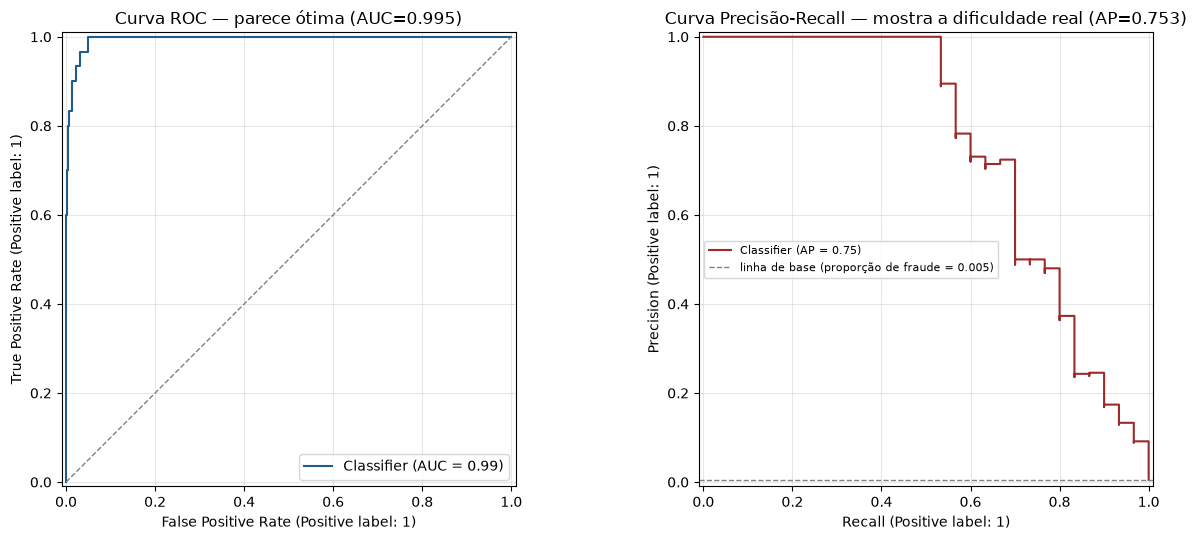

In [5]:
roc_auc = roc_auc_score(y_teste, probs)
pr_auc = average_precision_score(y_teste, probs)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
RocCurveDisplay.from_predictions(y_teste, probs, ax=axes[0], curve_kwargs={"color": AZUL})
axes[0].plot([0, 1], [0, 1], "--", color="gray", lw=1)
axes[0].set_title(f"Curva ROC — parece ótima (AUC={roc_auc:.3f})")

PrecisionRecallDisplay.from_predictions(y_teste, probs, ax=axes[1],
                                        curve_kwargs={"color": VERMELHO})
linha_base = y_teste.mean()
axes[1].axhline(linha_base, color="gray", ls="--", lw=1,
                label=f"linha de base (proporção de fraude = {linha_base:.3f})")
axes[1].set_title(f"Curva Precisão-Recall — mostra a dificuldade real (AP={pr_auc:.3f})")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**A ROC-AUC parece excelente** porque o eixo de falso-positivo é calculado
sobre a classe majoritária (imensa) — é fácil manter essa taxa baixa mesmo
capturando poucas fraudes. **A curva precisão-recall mostra a dificuldade
real**: a linha de base (o que um classificador aleatório alcançaria) é a
própria taxa de fraude, brutalmente baixa — qualquer ganho acima dela é
genuíno, e a curva revela o quanto a precisão cai conforme se exige mais
recall.

## O que levar deste notebook

- Acurácia alta em dados desbalanceados não significa nada — meça sempre
  contra o baseline "prever sempre a classe majoritária".
- Recall baixo com acurácia alta é a assinatura clássica de um modelo que
  não aprendeu a reconhecer a classe rara.
- ROC-AUC pode parecer artificialmente boa sob desbalanceamento severo;
  PR-AUC reflete melhor a dificuldade real do problema.

→ Próximo: **Técnicas de reamostragem** — o primeiro conjunto de correções
para esse problema.